### **Install libraries before running the code**
- pip install pandas
- pip install matplotlib
- pip install scikit-learn

# **Main Code**

In [455]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import os

# Remove the comment at the next line (path = "AmesHousing.csv") if you are using Google Colab and make sure to delete the next 2 lines after it!
# path = "AmesHousing.csv"

data_dir = 'data'
path = os.path.join(data_dir, "AmesHousing.csv")

a_housing = pd.read_csv(path)
pd.set_option('display.max_columns', None)

In [456]:
a_housing.shape

(2930, 82)

In [457]:
a_housing.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [458]:
a_housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [459]:
a_housing.nunique().to_dict()

{'Order': 2930,
 'PID': 2930,
 'MS SubClass': 16,
 'MS Zoning': 7,
 'Lot Frontage': 128,
 'Lot Area': 1960,
 'Street': 2,
 'Alley': 2,
 'Lot Shape': 4,
 'Land Contour': 4,
 'Utilities': 3,
 'Lot Config': 5,
 'Land Slope': 3,
 'Neighborhood': 28,
 'Condition 1': 9,
 'Condition 2': 8,
 'Bldg Type': 5,
 'House Style': 8,
 'Overall Qual': 10,
 'Overall Cond': 9,
 'Year Built': 118,
 'Year Remod/Add': 61,
 'Roof Style': 6,
 'Roof Matl': 8,
 'Exterior 1st': 16,
 'Exterior 2nd': 17,
 'Mas Vnr Type': 4,
 'Mas Vnr Area': 445,
 'Exter Qual': 4,
 'Exter Cond': 5,
 'Foundation': 6,
 'Bsmt Qual': 5,
 'Bsmt Cond': 5,
 'Bsmt Exposure': 4,
 'BsmtFin Type 1': 6,
 'BsmtFin SF 1': 995,
 'BsmtFin Type 2': 6,
 'BsmtFin SF 2': 274,
 'Bsmt Unf SF': 1137,
 'Total Bsmt SF': 1058,
 'Heating': 6,
 'Heating QC': 5,
 'Central Air': 2,
 'Electrical': 5,
 '1st Flr SF': 1083,
 '2nd Flr SF': 635,
 'Low Qual Fin SF': 36,
 'Gr Liv Area': 1292,
 'Bsmt Full Bath': 4,
 'Bsmt Half Bath': 3,
 'Full Bath': 5,
 'Half Bath': 3,

In [460]:
# counting null values and the persentages of them
missing_value = a_housing.isnull().sum()
missing_percintage = (missing_value / len(a_housing))*100 

missing_summary = pd.DataFrame ({

     "null%": missing_value,
     "Percintage": missing_percintage
     
    }).sort_values(by = 'Percintage' ,  ascending=False)
missing_summary.head(30)

,null%,Percintage
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423
Lot Frontage,490,16.723549
Garage Qual,159,5.426621
Garage Yr Blt,159,5.426621
Garage Cond,159,5.426621


In [461]:
a_housing.isnull().sum().to_dict()

{'Order': 0,
 'PID': 0,
 'MS SubClass': 0,
 'MS Zoning': 0,
 'Lot Frontage': 490,
 'Lot Area': 0,
 'Street': 0,
 'Alley': 2732,
 'Lot Shape': 0,
 'Land Contour': 0,
 'Utilities': 0,
 'Lot Config': 0,
 'Land Slope': 0,
 'Neighborhood': 0,
 'Condition 1': 0,
 'Condition 2': 0,
 'Bldg Type': 0,
 'House Style': 0,
 'Overall Qual': 0,
 'Overall Cond': 0,
 'Year Built': 0,
 'Year Remod/Add': 0,
 'Roof Style': 0,
 'Roof Matl': 0,
 'Exterior 1st': 0,
 'Exterior 2nd': 0,
 'Mas Vnr Type': 1775,
 'Mas Vnr Area': 23,
 'Exter Qual': 0,
 'Exter Cond': 0,
 'Foundation': 0,
 'Bsmt Qual': 80,
 'Bsmt Cond': 80,
 'Bsmt Exposure': 83,
 'BsmtFin Type 1': 80,
 'BsmtFin SF 1': 1,
 'BsmtFin Type 2': 81,
 'BsmtFin SF 2': 1,
 'Bsmt Unf SF': 1,
 'Total Bsmt SF': 1,
 'Heating': 0,
 'Heating QC': 0,
 'Central Air': 0,
 'Electrical': 1,
 '1st Flr SF': 0,
 '2nd Flr SF': 0,
 'Low Qual Fin SF': 0,
 'Gr Liv Area': 0,
 'Bsmt Full Bath': 2,
 'Bsmt Half Bath': 2,
 'Full Bath': 0,
 'Half Bath': 0,
 'Bedroom AbvGr': 0,
 'Ki

In [462]:
# droping unnessesary columns or that have alot of null values
columns_to_be_droped = ['Order','PID','Pool QC','Misc Feature','Alley','Fence','Mas Vnr Type']
cleaned_data = a_housing.drop(columns=columns_to_be_droped)

# missing value --> numerical values

# filling null values
cleaned_data ['Garage Yr Blt'] = cleaned_data['Garage Yr Blt'].fillna(cleaned_data['Year Built'])

# median
cleaned_data2 = ['Mas Vnr Area','BsmtFin SF 1','BsmtFin SF 2','Bsmt Unf SF','Total Bsmt SF','Bsmt Full Bath','Bsmt Half Bath','Garage Cars','Garage Area','Lot Frontage']
for column in cleaned_data2:
    cleaned_data[column] = cleaned_data[column].fillna (cleaned_data[column].median())

# mode
categorical_columns = ['Fireplace Qu', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Garage Type']
for column in categorical_columns:
    cleaned_data[column] = cleaned_data[column].fillna(cleaned_data[column].mode()[0])
cleaned_data

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,Gd,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,Gd,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,RL,37.0,7937,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,Norm,1Fam,SLvl,6,6,1984,1984,Gable,CompShg,HdBoard,HdBoard,0.0,TA,TA,CBlock,TA,TA,Av,GLQ,819.0,Unf,0.0,184.0,1003.0,GasA,TA,Y,SBrkr,1003,0,0,1003,1.0,0.0,1,0,3,1,TA,6,Typ,0,Gd,Detchd,1984.0,Unf,2.0,588.0,TA,TA,Y,120,0,0,0,0,0,0,3,2006,WD,Normal,142500
2926,20,RL,68.0,8885,Pave,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,1Story,5,5,1983,1983,Gable,CompShg,HdBoard,HdBoard,0.0,TA,TA,CBlock,Gd,TA,Av,BLQ,301.0,ALQ,324.0,239.0,864.0,GasA,TA,Y,SBrkr,902,0,0,902,1.0,0.0,1,0,2,1,TA,5,Typ,0,Gd,Attchd,1983.0,Unf,2.0,484.0,TA,TA,Y,164,0,0,0,0,0,0,6,2006,WD,Normal,131000
2927,85,RL,62.0,10441,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,0.0,TA,TA,PConc,Gd,TA,Av,GLQ,337.0,Unf,0.0,575.0,912.0,GasA,TA,Y,SBrkr,970,0,0,970,0.0,1.0,1,0,3,1,TA,6,Typ,0,Gd,Attchd,1992.0,Unf,0.0,0.0,TA,TA,Y,80,32,0,0,0,0,700,7,2006,WD,Normal,132000
2928,20,RL,77.0,10010,Pave,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,1Story,5,5,1974,1975,Gable,CompShg,HdBoard,HdBoard,0.0,TA,TA,CBlock,Gd,TA,Av,ALQ,1071.0,LwQ,123.0,195.0,1389.0,GasA,Gd,Y,SBrkr,1389,0,0,1389,1.0,0.0,1,0,2,1,TA,6,Typ,1,TA,Attchd,1975.0,RFn,

In [463]:
cleaned_data.isnull().sum().to_dict()

{'MS SubClass': 0,
 'MS Zoning': 0,
 'Lot Frontage': 0,
 'Lot Area': 0,
 'Street': 0,
 'Lot Shape': 0,
 'Land Contour': 0,
 'Utilities': 0,
 'Lot Config': 0,
 'Land Slope': 0,
 'Neighborhood': 0,
 'Condition 1': 0,
 'Condition 2': 0,
 'Bldg Type': 0,
 'House Style': 0,
 'Overall Qual': 0,
 'Overall Cond': 0,
 'Year Built': 0,
 'Year Remod/Add': 0,
 'Roof Style': 0,
 'Roof Matl': 0,
 'Exterior 1st': 0,
 'Exterior 2nd': 0,
 'Mas Vnr Area': 0,
 'Exter Qual': 0,
 'Exter Cond': 0,
 'Foundation': 0,
 'Bsmt Qual': 80,
 'Bsmt Cond': 80,
 'Bsmt Exposure': 83,
 'BsmtFin Type 1': 80,
 'BsmtFin SF 1': 0,
 'BsmtFin Type 2': 81,
 'BsmtFin SF 2': 0,
 'Bsmt Unf SF': 0,
 'Total Bsmt SF': 0,
 'Heating': 0,
 'Heating QC': 0,
 'Central Air': 0,
 'Electrical': 1,
 '1st Flr SF': 0,
 '2nd Flr SF': 0,
 'Low Qual Fin SF': 0,
 'Gr Liv Area': 0,
 'Bsmt Full Bath': 0,
 'Bsmt Half Bath': 0,
 'Full Bath': 0,
 'Half Bath': 0,
 'Bedroom AbvGr': 0,
 'Kitchen AbvGr': 0,
 'Kitchen Qual': 0,
 'TotRms AbvGrd': 0,
 'Functi

In [464]:
# verify that no significant missing values remain
remaining_missing = cleaned_data.isnull().sum()
remaining_missing_summary = remaining_missing[remaining_missing > 0]

cleaned_data.shape, remaining_missing_summary

((2930, 75),
 Bsmt Qual         80
 Bsmt Cond         80
 Bsmt Exposure     83
 BsmtFin Type 1    80
 BsmtFin Type 2    81
 Electrical         1
 dtype: int64)

In [465]:
# handling missing data
basement_cols = ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']
cleaned_data[basement_cols] = cleaned_data[basement_cols].fillna('none')

In [466]:
# Option A: Fill with mode
cleaned_data['Electrical'] = cleaned_data['Electrical'].fillna(cleaned_data['Electrical'].mode()[0])

# # Option B: Drop the row
# cleaned_data = cleaned_data.dropna(subset=['Electrical'])

In [467]:
cleaned_data.duplicated().sum()

np.int64(0)

In [468]:
# creating one column to reduce the columns

cleaned_data ['total SF'] = (cleaned_data['1st Flr SF'] + cleaned_data ['2nd Flr SF'] + cleaned_data ['Total Bsmt SF'])

cleaned_data ['total bathrooms'] = (cleaned_data['Bsmt Full Bath']+(cleaned_data['Bsmt Half Bath'] * 0.5) + cleaned_data['Full Bath']+(cleaned_data['Half Bath'] * 0.5))

cleaned_data ['house age'] = (cleaned_data['Yr Sold'] - cleaned_data['Year Built'])

cleaned_data ['remodeled'] = (cleaned_data['Year Remod/Add'] > cleaned_data['Year Built']).astype(int)

cleaned_data ['avarage sf per room'] = cleaned_data ['total SF'] / cleaned_data ['TotRms AbvGrd']

cleaned_data ['garage age'] = cleaned_data['Garage Yr Blt'] - cleaned_data['Year Built']

cleaned_data['Quality Index'] = cleaned_data['Overall Qual'] * cleaned_data['Overall Cond']

cleaned_data['Lot Utilization'] = cleaned_data['total SF'] / cleaned_data['Lot Area']

cleaned_data['Age When Sold'] = cleaned_data['house age'] + cleaned_data['garage age']

# dropping columns
columns_to_be_droped = ['1st Flr SF' , '2nd Flr SF' , 'Total Bsmt SF',
                        'Bsmt Half Bath' , 'Full Bath' , 'Half Bath',
                        'Yr Sold' , 'Year Remod/Add' , 'TotRms AbvGrd',
                        'Garage Yr Blt' , 'Overall Qual' , 'Overall Cond' ,
                        'Garage Cars' , 'garage age' , 'Age When Sold']

cleaned_data = cleaned_data.drop(columns= columns_to_be_droped)

cleaned_data

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Year Built,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Heating,Heating QC,Central Air,Electrical,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Finish,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Sale Type,Sale Condition,SalePrice,total SF,total bathrooms,house age,remodeled,avarage sf per room,Quality Index,Lot Utilization
0,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,1960,Hip,CompShg,BrkFace,Plywood,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,GasA,Fa,Y,SBrkr,0,1656,1.0,3,1,TA,Typ,2,Gd,Attchd,Fin,528.0,TA,TA,P,210,62,0,0,0,0,0,5,WD,Normal,215000,2736.0,2.0,50,0,390.857143,30,0.086119
1,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,1961,Gable,CompShg,VinylSd,VinylSd,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,GasA,TA,Y,SBrkr,0,896,0.0,2,1,TA,Typ,0,Gd,Attchd,Unf,730.0,TA,TA,Y,140,0,0,0,120,0,0,6,WD,Normal,105000,1778.0,1.0,49,0,355.600000,30,0.152986
2,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,1958,Hip,CompShg,Wd Sdng,Wd Sdng,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,GasA,TA,Y,SBrkr,0,1329,0.0,3,1,Gd,Typ,0,Gd,Attchd,Unf,312.0,TA,TA,Y,393,36,0,0,0,0,12500,6,WD,Normal,172000,2658.0,1.5,52,0,443.000000,36,0.186304
3,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,1968,Hip,CompShg,BrkFace,BrkFace,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,GasA,Ex,Y,SBrkr,0,2110,1.0,3,1,Ex,Typ,2,TA,Attchd,Fin,522.0,TA,TA,Y,0,0,0,0,0,0,0,4,WD,Normal,244000,4220.0,3.5,42,0,527.500000,35,0.378136
4,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,1997,Gable,CompShg,VinylSd,VinylSd,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,GasA,Gd,Y,SBrkr,0,1629,0.0,3,1,TA,Typ,1,TA,Attchd,Fin,482.0,TA,TA,Y,212,34,0,0,0,0,0,3,WD,Normal,189900,2557.0,2.5,13,1,426.166667,25,0.184888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,RL,37.0,7937,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,Norm,1Fam,SLvl,1984,Gable,CompShg,HdBoard,HdBoard,0.0,TA,TA,CBlock,TA,TA,Av,GLQ,819.0,Unf,0.0,184.0,GasA,TA,Y,SBrkr,0,1003,1.0,3,1,TA,Typ,0,Gd,Detchd,Unf,588.0,TA,TA,Y,120,0,0,0,0,0,0,3,WD,Normal,142500,2006.0,2.0,22,0,334.333333,36,0.252740
2926,20,RL,68.0,8885,Pave,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,1Story,1983,Gable,CompShg,HdBoard,HdBoard,0.0,TA,TA,CBlock,Gd,TA,Av,BLQ,301.0,ALQ,324.0,239.0,GasA,TA,Y,SBrkr,0,902,1.0,2,1,TA,Typ,0,Gd,Attchd,Unf,484.0,TA,TA,Y,164,0,0,0,0,0,0,6,WD,Normal,131000,1766.0,2.0,23,0,353.200000,25,0.198762
2927,85,RL,62.0,10441,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,1992,Gable,CompShg,HdBoard,Wd Shng,0.0,TA,TA,PConc,Gd,TA,Av,GLQ,337.0,Unf,0.0,575.0,GasA,TA,Y,SBrkr,0,970,0.0,3,1,TA,Typ,0,Gd,Attchd,Unf,0.0,TA,TA,Y,80,32,0,0,0,0,700,7,WD,Normal,132000,1882.0,1.5,14,0,313.666667,25,0.180251
2928,20,RL,77.0,10010,Pave,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,1Story,1974,Gable,CompShg,HdBoard,HdBoard,0.0,TA,TA,CBlock,Gd,TA,Av,ALQ,1071.0,LwQ,123.0,195.0,GasA,Gd,Y,SBrkr,0,1389,1.0,2,1,TA,Typ,1,TA,Attchd,RFn,418.0,TA,TA,Y,240,38,0,0,0,0,0,4,WD,Normal,170000,2778.0,2.0,32,1,463.000000,25,0.277522


In [469]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 69 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MS SubClass          2930 non-null   int64  
 1   MS Zoning            2930 non-null   str    
 2   Lot Frontage         2930 non-null   float64
 3   Lot Area             2930 non-null   int64  
 4   Street               2930 non-null   str    
 5   Lot Shape            2930 non-null   str    
 6   Land Contour         2930 non-null   str    
 7   Utilities            2930 non-null   str    
 8   Lot Config           2930 non-null   str    
 9   Land Slope           2930 non-null   str    
 10  Neighborhood         2930 non-null   str    
 11  Condition 1          2930 non-null   str    
 12  Condition 2          2930 non-null   str    
 13  Bldg Type            2930 non-null   str    
 14  House Style          2930 non-null   str    
 15  Year Built           2930 non-null   int64  
 16 

In [470]:
# checking for values < 0 or values that doesn't make sense for the new added features

cleaned_data[['total SF', 'total bathrooms', 'house age', 'remodeled', 'avarage sf per room']].describe()

,total SF,total bathrooms,house age,remodeled,avarage sf per room
count,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,2546.607167,2.217918,36.434130,0.464164,399.053417
std,803.865160,0.807444,30.291357,0.498799,94.283641
min,334.000000,1.000000,-1.000000,0.000000,128.000000
25%,2000.000000,1.500000,7.000000,0.000000,341.000000
50%,2450.000000,2.000000,34.000000,0.000000,387.183333
75%,2990.000000,2.500000,54.000000,1.000000,450.767857
max,11752.000000,7.000000,136.000000,1.000000,979.333333


In [471]:
# we can see that the house age is less than 0 and that doesn't make sense...

In [472]:
# fixing values < 0

cleaned_data = cleaned_data.reset_index(drop=True)

for i in range(len(cleaned_data)):
    if cleaned_data.loc[i, 'house age'] < 0:
        cleaned_data.loc[i, 'house age'] = 0

cleaned_data['house age'].describe() # checked _/

count    2930.000000
mean       36.434471
std        30.290941
min         0.000000
25%         7.000000
50%        34.000000
75%        54.000000
max       136.000000
Name: house age, dtype: float64

In [473]:
# data shape after cleaning
cleaned_data.shape

(2930, 69)

In [474]:
categorical = cleaned_data.select_dtypes(include= ['object']).columns
categorical

C:\Users\volca\AppData\Local\Temp\ipykernel_23388\2922694602.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = cleaned_data.select_dtypes(include= ['object']).columns


Index(['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Exter Qual', 'Exter Cond',
       'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Sale Type', 'Sale Condition'],
      dtype='str')

In [475]:
cleaned_data.isnull().value_counts()

MS SubClass  MS Zoning  Lot Frontage  Lot Area  Street  Lot Shape  Land Contour  Utilities  Lot Config  Land Slope  Neighborhood  Condition 1  Condition 2  Bldg Type  House Style  Year Built  Roof Style  Roof Matl  Exterior 1st  Exterior 2nd  Mas Vnr Area  Exter Qual  Exter Cond  Foundation  Bsmt Qual  Bsmt Cond  Bsmt Exposure  BsmtFin Type 1  BsmtFin SF 1  BsmtFin Type 2  BsmtFin SF 2  Bsmt Unf SF  Heating  Heating QC  Central Air  Electrical  Low Qual Fin SF  Gr Liv Area  Bsmt Full Bath  Bedroom AbvGr  Kitchen AbvGr  Kitchen Qual  Functional  Fireplaces  Fireplace Qu  Garage Type  Garage Finish  Garage Area  Garage Qual  Garage Cond  Paved Drive  Wood Deck SF  Open Porch SF  Enclosed Porch  3Ssn Porch  Screen Porch  Pool Area  Misc Val  Mo Sold  Sale Type  Sale Condition  SalePrice  total SF  total bathrooms  house age  remodeled  avarage sf per room  Quality Index  Lot Utilization
False        False      False         False     False   False      False         False      False      

In [476]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 69 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MS SubClass          2930 non-null   int64  
 1   MS Zoning            2930 non-null   str    
 2   Lot Frontage         2930 non-null   float64
 3   Lot Area             2930 non-null   int64  
 4   Street               2930 non-null   str    
 5   Lot Shape            2930 non-null   str    
 6   Land Contour         2930 non-null   str    
 7   Utilities            2930 non-null   str    
 8   Lot Config           2930 non-null   str    
 9   Land Slope           2930 non-null   str    
 10  Neighborhood         2930 non-null   str    
 11  Condition 1          2930 non-null   str    
 12  Condition 2          2930 non-null   str    
 13  Bldg Type            2930 non-null   str    
 14  House Style          2930 non-null   str    
 15  Year Built           2930 non-null   int64  
 16 

In [477]:
# after filling missing values in ordinal columns with the mode, we can apply ordinal encoding

ordinal = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 
           'Bsmt Cond', 'Heating QC', 'Kitchen Qual', 
           'Functional', 'Paved Drive', 'Lot Shape',
           'Land Slope', 'Bsmt Exposure', 'Fireplace Qu',
           'Garage Finish', 'Garage Qual', 'Garage Cond']

# filling missing values with mode
for column in ordinal:
    cleaned_data[column].fillna(cleaned_data[column].mode()[0], inplace=True)

#	Column	Order (worst → best)
catagorical = [
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                               # Exter Qual
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                               # Exter Cond
    ['none', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],                       # Bsmt Qual
    ['none', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],                       # Bsmt Cond
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                               # Heating QC
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                               # Kitchen Qual
    ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'], # Functional
    ['N', 'P', 'Y'],                                               # Paved Drive
    ['Reg', 'IR1', 'IR2', 'IR3'],                                  # Lot Shape
    ['Gtl', 'Mod', 'Sev'],                                         # Land Slope
    ['none', 'No', 'Mn', 'Av', 'Gd'],                             # Bsmt Exposure
    ['none', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],                       # Fireplace Qu
    ['none', 'Unf', 'RFn', 'Fin'],                                 # Garage Finish
    ['none', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],                       # Garage Qual
    ['none', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],                       # Garage Cond
]

ordinal_encoder = OrdinalEncoder(categories=catagorical)
cleaned_data[ordinal] = ordinal_encoder.fit_transform(cleaned_data[ordinal])
cleaned_data[ordinal] = cleaned_data[ordinal].astype(int)

C:\Users\volca\AppData\Local\Temp\ipykernel_23388\1691282909.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  cleaned_data[column].fillna(cleaned_data[column].mode()[0], inplace=True)


In [478]:
cleaned_data.shape

(2930, 69)

In [479]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 69 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MS SubClass          2930 non-null   int64  
 1   MS Zoning            2930 non-null   str    
 2   Lot Frontage         2930 non-null   float64
 3   Lot Area             2930 non-null   int64  
 4   Street               2930 non-null   str    
 5   Lot Shape            2930 non-null   int64  
 6   Land Contour         2930 non-null   str    
 7   Utilities            2930 non-null   str    
 8   Lot Config           2930 non-null   str    
 9   Land Slope           2930 non-null   int64  
 10  Neighborhood         2930 non-null   str    
 11  Condition 1          2930 non-null   str    
 12  Condition 2          2930 non-null   str    
 13  Bldg Type            2930 non-null   str    
 14  House Style          2930 non-null   str    
 15  Year Built           2930 non-null   int64  
 16 

In [480]:
# one hot encoded for catagorical features
nominal_features = [
    'MS Zoning', 'Street', 'Land Contour', 'Neighborhood', 'Condition 1',
    'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
    'Exterior 1st', 'Exterior 2nd', 'Foundation', 'Heating', 'Garage Type',
    'Paved Drive', 'Sale Type', 'Sale Condition' , 'Utilities' , 'Lot Config' , 
    'BsmtFin Type 1' , 'BsmtFin Type 2' , 'Electrical' , 'Central Air'
]


one_hot_encoder = OneHotEncoder(sparse_output = False , drop = None)

encoded_data = one_hot_encoder.fit_transform(cleaned_data[nominal_features])

encoded_feature_names = one_hot_encoder.get_feature_names_out(nominal_features)
encoded_df = pd.DataFrame(encoded_data, columns = encoded_feature_names , index = cleaned_data.index)

cleaned_data = pd.concat([cleaned_data.drop(columns = nominal_features) , encoded_df] , axis = 1)

In [481]:
cleaned_data.head()

,MS SubClass,Lot Frontage,Lot Area,Lot Shape,Land Slope,Year Built,Mas Vnr Area,Exter Qual,Exter Cond,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Heating QC,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,Functional,Fireplaces,Fireplace Qu,Garage Finish,Garage Area,Garage Qual,Garage Cond,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,SalePrice,total SF,total bathrooms,house age,remodeled,avarage sf per room,Quality Index,Lot Utilization,MS Zoning_A (agr),MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM,Street_Grvl,Street_Pave,Land Contour_Bnk,Land Contour_HLS,Land Contour_Low,Land Contour_Lvl,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,Neighborhood_GrnHill,Neighborhood_IDOTRR,Neighborhood_Landmrk,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition 1_Artery,Condition 1_Feedr,Condition 1_Norm,Condition 1_PosA,Condition 1_PosN,Condition 1_RRAe,Condition 1_RRAn,Condition 1_RRNe,Condition 1_RRNn,Condition 2_Artery,Condition 2_Feedr,Condition 2_Norm,Condition 2_PosA,Condition 2_PosN,Condition 2_RRAe,Condition 2_RRAn,Condition 2_RRNn,Bldg Type_1Fam,Bldg Type_2fmCon,Bldg Type_Duplex,Bldg Type_Twnhs,Bldg Type_TwnhsE,House Style_1.5Fin,House Style_1.5Unf,House Style_1Story,House Style_2.5Fin,House Style_2.5Unf,House Style_2Story,House Style_SFoyer,House Style_SLvl,Roof Style_Flat,Roof Style_Gable,Roof Style_Gambrel,Roof Style_Hip,Roof Style_Mansard,Roof Style_Shed,Roof Matl_ClyTile,Roof Matl_CompShg,Roof Matl_Membran,Roof Matl_Metal,Roof Matl_Roll,Roof Matl_Tar&Grv,Roof Matl_WdShake,Roof Matl_WdShngl,Exterior 1st_AsbShng,Exterior 1st_AsphShn,Exterior 1st_BrkComm,Exterior 1st_BrkFace,Exterior 1st_CBlock,Exterior 1st_CemntBd,Exterior 1st_HdBoard,Exterior 1st_ImStucc,Exterior 1st_MetalSd,Exterior 1st_Plywood,Exterior 1st_PreCast,Exterior 1st_Stone,Exterior 1st_Stucco,Exterior 1st_VinylSd,Exterior 1st_Wd Sdng,Exterior 1st_WdShing,Exterior 2nd_AsbShng,Exterior 2nd_AsphShn,Exterior 2nd_Brk Cmn,Exterior 2nd_BrkFace,Exterior 2nd_CBlock,Exterior 2nd_CmentBd,Exterior 2nd_HdBoard,Exterior 2nd_ImStucc,Exterior 2nd_MetalSd,Exterior 2nd_Other,Exterior 2nd_Plywood,Exterior 2nd_PreCast,Exterior 2nd_Stone,Exterior 2nd_Stucco,Exterior 2nd_VinylSd,Exterior 2nd_Wd Sdng,Exterior 2nd_Wd Shng,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Garage Type_2Types,Garage Type_Attchd,Garage Type_Basment,Garage Type_BuiltIn,Garage Type_CarPort,Garage Type_Detchd,Paved Drive_0,Paved Drive_1,Paved Drive_2,Sale Type_COD,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial,Utilities_AllPub,Utilities_NoSeWa,Utilities_NoSewr,Lot Config_Corner,Lot Config_CulDSac,Lot Config_FR2,Lot Config_FR3,Lot Config_Inside,BsmtFin Type 1_ALQ,BsmtFin Type 1_BLQ,BsmtFin Type 1_GLQ,BsmtFin Type 1_LwQ,BsmtFin Type 1_Rec,BsmtFin Type 1_Unf,BsmtFin Type 1_none,BsmtFin Type 2_ALQ,BsmtFin Type 2_BLQ,BsmtFin Type 2_GLQ,BsmtFin Type 2_LwQ,BsmtFin Type 2_Rec,BsmtFin Type 2_Unf,BsmtFin Type 2_none,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,Central Air_N,Central Air_Y
0,20,141.0,31770,1,0,1960,112.0,2,2,3,4,4,639.0,0.0,441.0,1,0,1656,1.0,3,1,2,7,2,4,3,5

In [482]:
cleaned_data.shape

(2930, 229)

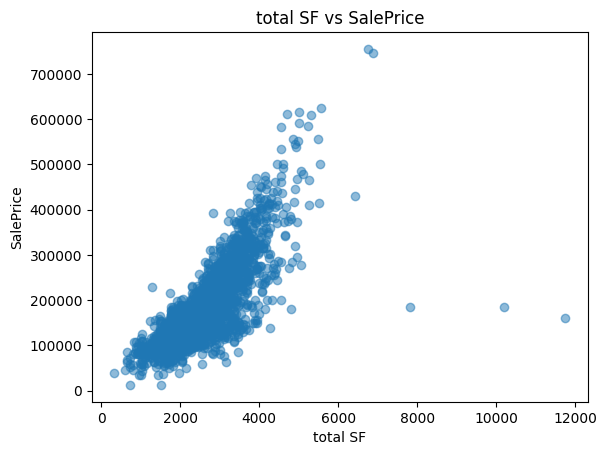

In [483]:
# SalePrice vs total SF
plt.scatter(cleaned_data['total SF'], cleaned_data['SalePrice'], alpha=0.5)
plt.title('total SF vs SalePrice')
plt.xlabel('total SF')
plt.ylabel('SalePrice')
plt.show()

In [484]:
print(cleaned_data.select_dtypes(include=['object']).columns)
cleaned_data.shape

Index([], dtype='str')


(2930, 229)

In [485]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Columns: 229 entries, MS SubClass to Central Air_Y
dtypes: float64(195), int64(34)
memory usage: 5.1 MB


In [486]:
print(cleaned_data.head())

   MS SubClass  Lot Frontage  Lot Area  Lot Shape  Land Slope  Year Built  \
0           20         141.0     31770          1           0        1960   
1           20          80.0     11622          0           0        1961   
2           20          81.0     14267          1           0        1958   
3           20          93.0     11160          0           0        1968   
4           60          74.0     13830          1           0        1997   

   Mas Vnr Area  Exter Qual  Exter Cond  Bsmt Qual  Bsmt Cond  Bsmt Exposure  \
0         112.0           2           2          3          4              4   
1           0.0           2           2          3          3              1   
2         108.0           2           2          3          3              1   
3           0.0           3           2          3          3              1   
4           0.0           2           2          4          3              1   

   BsmtFin SF 1  BsmtFin SF 2  Bsmt Unf SF  Heating QC  

In [487]:
print(cleaned_data.columns)

Index(['MS SubClass', 'Lot Frontage', 'Lot Area', 'Lot Shape', 'Land Slope',
       'Year Built', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Bsmt Qual',
       ...
       'BsmtFin Type 2_Rec', 'BsmtFin Type 2_Unf', 'BsmtFin Type 2_none',
       'Electrical_FuseA', 'Electrical_FuseF', 'Electrical_FuseP',
       'Electrical_Mix', 'Electrical_SBrkr', 'Central Air_N', 'Central Air_Y'],
      dtype='str', length=229)


In [488]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Columns: 229 entries, MS SubClass to Central Air_Y
dtypes: float64(195), int64(34)
memory usage: 5.1 MB


In [489]:
from sklearn.model_selection import train_test_split

x = cleaned_data.drop(columns = ['SalePrice'])
y = cleaned_data ['SalePrice']

x_train , x_test , y_train , y_test = train_test_split (x , y , test_size = 0.25 , random_state = 42 )

print("x_training shape " , x_train.shape)
print("x_testing shape " , x_test.shape)
print('y_training shape:', y_train.shape)
print('y_testing shape:', y_test.shape)

x_training shape  (2197, 228)
x_testing shape  (733, 228)
y_training shape: (2197,)
y_testing shape: (733,)


In [490]:
scaler = StandardScaler()

scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

print('x_train_scaled shape: ' , x_train_scaled.shape)
print('x_test_scaled shape: ' , x_test_scaled.shape)
print('y_training_scaled shape: ', y_train.shape)
print('y_testing_scaled shape: ', y_test.shape)

x_train_scaled shape:  (2197, 228)
x_test_scaled shape:  (733, 228)
y_training_scaled shape:  (2197,)
y_testing_scaled shape:  (733,)


In [491]:
# importing MSE and R2
from sklearn.metrics import mean_squared_error, r2_score

In [492]:
# KNN
from sklearn.neighbors import KNeighborsRegressor

# after gridsearch
knn = KNeighborsRegressor(n_neighbors = 5, weights = 'uniform', metric = 'manhattan')

# training
knn.fit(x_train_scaled, y_train)

# making predictions
y_prediction_train_knn = knn.predict(x_train_scaled)
y_prediction_test_knn = knn.predict(x_test_scaled)

# RMSE

train_rmse_knn = mean_squared_error(y_train , y_prediction_train_knn) ** 0.5
test_rmse_knn = mean_squared_error(y_test , y_prediction_test_knn) ** 0.5

# R2
r2_knn = r2_score(y_test, y_prediction_test_knn)

print("knn regression:")
print('test RMSE: ' , test_rmse_knn)
print('train RMSE: ', train_rmse_knn)
print('R2: ' , r2_knn)
print('score: ', knn.score(x_test_scaled, y_test))

knn regression:
test RMSE:  37184.4054799363
train RMSE:  29031.461010046056
R2:  0.8103338924852916
score:  0.8103338924852916


In [493]:
# from sklearn.neighbors import KNeighborsRegressor

# knn_params = {'n_neighbors': [3, 5, 7, 9, 11, 15], 'metric': ['euclidean', 'manhattan']}
# knn = GridSearchCV(KNeighborsRegressor(), knn_params, cv=5, scoring='neg_mean_squared_error', refit=True)
# knn.fit(x_train_scaled, y_train)
# print("Best KNN parameters:", knn.best_params_)

# Best KNN parameters: {'metric': 'manhattan', 'n_neighbors': 5}

In [494]:
#LR
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

# training
lr.fit(x_train_scaled, y_train)

# making predictions
y_prediction_train_lr = lr.predict(x_train_scaled)
y_prediction_test_lr = lr.predict(x_test_scaled)

# RMSE
train_rmse_lenear = mean_squared_error(y_train , y_prediction_train_lr) ** 0.5
test_rmse_lenear = mean_squared_error(y_test , y_prediction_test_lr) ** 0.5

# R2
r2_lenear = r2_score(y_test, y_prediction_test_lr)

print('lenear regression:')
print('test RMSE: ' , test_rmse_lenear)
print('train RMSE: ' , train_rmse_lenear)
print('R2: ', r2_lenear)
print('score: ', lr.score(x_test_scaled, y_test))

lenear regression:
test RMSE:  28943.039643378343
train RMSE:  22475.796431653016
R2:  0.8850903965581663
score:  0.8850903965581663


In [495]:
# RIDGE
from sklearn.linear_model import Ridge

# after gridsearch
ridge = Ridge(random_state= 42 , alpha = 1000, solver = 'svd')

# training
ridge.fit(x_train_scaled, y_train)

# making predictions
y_prediction_train_ridge = ridge.predict(x_train_scaled)
y_prediction_test_ridge = ridge.predict(x_test_scaled)

# RMSE
train_rmse_ridge = mean_squared_error(y_train , y_prediction_train_ridge) ** 0.5
test_rmse_ridge = mean_squared_error(y_test , y_prediction_test_ridge) ** 0.5

# R2
r2_ridge = r2_score(y_test, y_prediction_test_ridge)

print("ridge regression:")
print('test RMSE: ' , test_rmse_ridge)
print('train RMSE: ', train_rmse_ridge)
print('R2: ' , r2_ridge)
print('score: ', ridge.score(x_test_scaled, y_test))

ridge regression:
test RMSE:  30354.945474040545
train RMSE:  24889.948909730752
R2:  0.8736058536309063
score:  0.8736058536309063


In [496]:
# from sklearn.linear_model import Ridge

# ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000] , 'solver' : ['auto', 'svd', 'cholesky']}
# ridge = GridSearchCV(Ridge(), ridge_params , cv = 5, scoring='neg_root_mean_squared_error', refit=True)
# ridge.fit(x_train_scaled , y_train)
# print("Best Ridge Parameters: " , ridge.best_params_)

# Best Ridge Parameters:  {'alpha': 1000, 'solver': 'svd'}


In [497]:
# Lasso
from sklearn.linear_model import Lasso

# after gridsearch
lasso = Lasso (random_state = 42 , alpha = 100 , max_iter = 5000)

# training
lasso.fit(x_train_scaled, y_train)

# making predictions
y_prediction_train_lasso = lasso.predict(x_train_scaled)
y_prediction_test_lasso = lasso.predict(x_test_scaled)

# RMSE
train_rmse_lasso = mean_squared_error(y_train, y_prediction_train_lasso) ** 0.5
test_rmse_lasso = mean_squared_error(y_test, y_prediction_test_lasso) ** 0.5

# R2
r2_lasso = r2_score(y_test, y_prediction_test_lasso)

print('lasso regression:')
print('test RMSE: ' , test_rmse_lasso)
print('train RMSE: ' , train_rmse_lasso)
print('R2: ', r2_lasso)
print('score: ', lasso.score(x_test_scaled, y_test))

lasso regression:
test RMSE:  28663.684918543193
train RMSE:  22583.467850741745
R2:  0.8872978789630779
score:  0.8872978789630779


In [498]:
# from sklearn.linear_model import Lasso

# lasso_params = {'alpha': [0.1, 1, 10, 100] , 'max_iter': [1000 , 2000, 5000]}
# lasso = GridSearchCV(Lasso() , lasso_params , cv = 5)
# lasso.fit(x_train, y_train)
# print("Best lasso parameters:", lasso.best_params_)

# Best lasso parameters: {'alpha': 100, 'max_iter': 5000}

decision tree regression:
test RMSE:  33012.62268438739
train RMSE:  27963.49414918122
R2:  0.8505045057628581
score:  0.8505045057628581


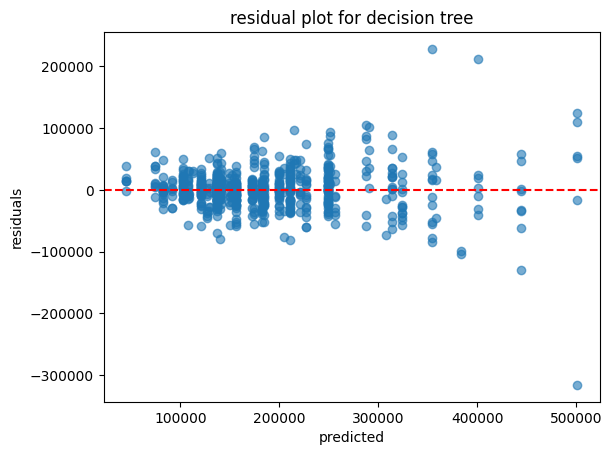

In [499]:
from sklearn.tree import DecisionTreeRegressor

# after gridsearch
dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=6,
    max_features=None,
    min_samples_leaf = 10,
    min_samples_split = 20
    )

# training
dt.fit(x_train, y_train)

# making predictions
y_prediction_train_dt = dt.predict(x_train)
y_prediction_test_dt = dt.predict(x_test)

# RMSE
train_rmse_dt = mean_squared_error(y_train, y_prediction_train_dt) ** 0.5
test_rmse_dt = mean_squared_error(y_test, y_prediction_test_dt) ** 0.5

# R2
r2_dt = r2_score(y_test, y_prediction_test_dt)

print('decision tree regression:')
print('test RMSE: ' , test_rmse_dt)
print('train RMSE: ' , train_rmse_dt)
print('R2: ', r2_dt)
print('score: ', dt.score(x_test, y_test))

dt_residuals = y_test - dt.predict(x_test)
plt.scatter(dt.predict(x_test) , dt_residuals , alpha = 0.6)
plt.axhline(0 , color = 'red' , linestyle = '--')
plt.title("residual plot for decision tree")
plt.xlabel("predicted")
plt.ylabel("residuals")
plt.show()

In [500]:
# from sklearn.tree import DecisionTreeRegressor

# dt_params = {
#     'max_depth': [3, 5, 6],
#     'min_samples_split': [10, 20, 50],
#     'min_samples_leaf': [5, 10, 20],
#     'max_features': ['sqrt', 'log2', None]
# }
# dt = GridSearchCV(DecisionTreeRegressor(), dt_params, cv = 5, scoring='neg_root_mean_squared_error', refit=True)
# dt.fit(x_train, y_train)
# print("Best decision tree parameters:", dt.best_params_)

# Best decision tree parameters: {'max_depth': 6, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 20}

random forest regression:
test RMSE:  27484.51684077985
train RMSE:  20051.737494875426
R2:  0.8963798395380955
score:  0.8963798395380955


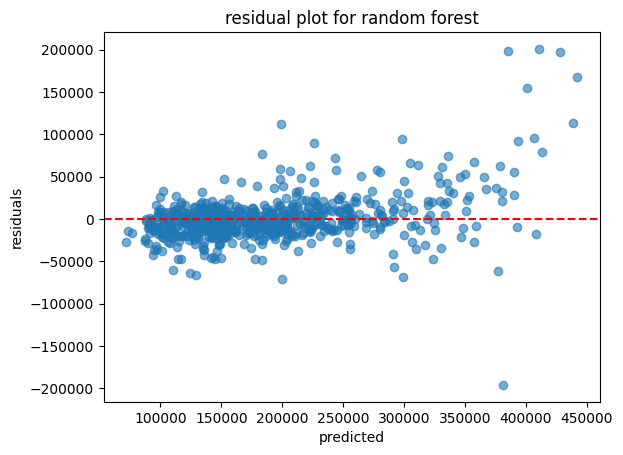

In [501]:
from sklearn.ensemble import RandomForestRegressor

# after gridsearch
rf = RandomForestRegressor(
    random_state = 42,
    n_estimators = 300,
    max_depth = 15,
    min_samples_split = 5,
    min_samples_leaf = 3,
    max_features='sqrt'
)
# trainig
rf.fit(x_train, y_train)

# making predictions
y_prediction_train_rfr = rf.predict(x_train)
y_prediction_test_rfr = rf.predict(x_test)

# RMSE
train_rmse_rfr = mean_squared_error(y_train, y_prediction_train_rfr) ** 0.5
test_rmse_rfr = mean_squared_error(y_test, y_prediction_test_rfr) ** 0.5

# R2
r2_rfr = r2_score(y_test, y_prediction_test_rfr)

print('random forest regression:')
print('test RMSE: ' , test_rmse_rfr)
print('train RMSE: ' , train_rmse_rfr)
print('R2: ', r2_rfr)
print('score: ', rf.score(x_test, y_test))


rf_residuals = y_test - rf.predict(x_test)
plt.scatter(rf.predict(x_test), rf_residuals, alpha = 0.6)
plt.axhline(0, color = 'red', linestyle = '--')
plt.title("residual plot for random forest")
plt.xlabel("predicted")
plt.ylabel("residuals")
plt.show()

In [502]:
# from sklearn.ensemble import RandomForestRegressor

# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [10, 15, 20, 25, None],
#     'min_samples_split': [5, 10, 20],
#     'min_samples_leaf': [2, 5, 10],
#     'max_features': ['sqrt', 'log2'],
# }

# grid_search = GridSearchCV(
#     estimator = rf, param_grid = param_grid, scoring = 'neg_root_mean_squared_error', cv = 5, verbose = 1, n_jobs = -1, refit = True
# )

# grid_search.fit(x_train , y_train)

# print("Best Random Forest parameters:", grid_search.best_params_)

# Best Random Forest parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}

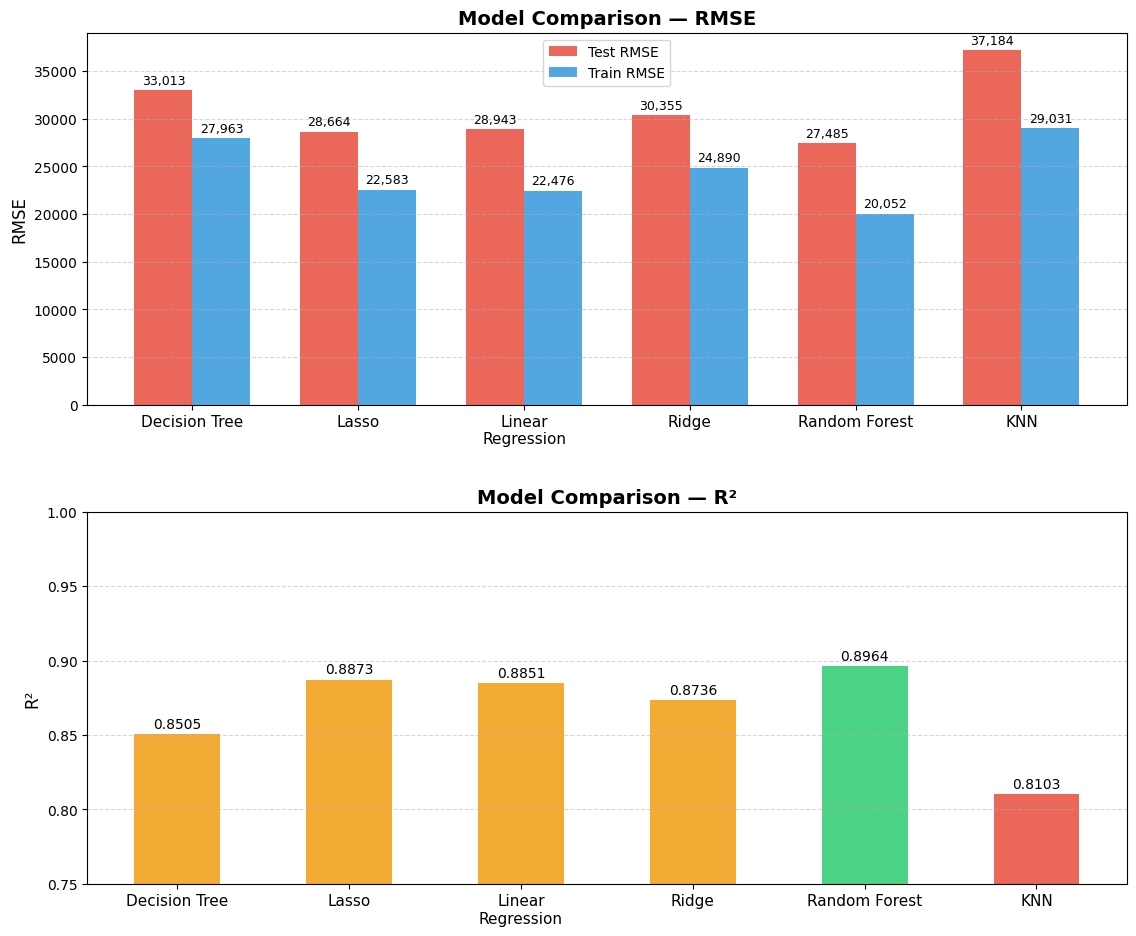

In [503]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Decision Tree', 'Lasso', 'Linear\nRegression', 'Ridge', 'Random Forest', 'KNN']
test_rmse = [33012.62, 28663.68, 28943.04, 30354.95, 27484.52, 37184.41]
train_rmse = [27963.49, 22583.47, 22475.80, 24889.95, 20051.74, 29031.46]
r2 = [0.8505, 0.8873, 0.8851, 0.8736, 0.8964, 0.8103]

x_pos = np.arange(len(models))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# RMSE plot
bars1 = ax1.bar(x_pos - width/2, test_rmse, width, label='Test RMSE', color='#e74c3c', alpha=0.85)
bars2 = ax1.bar(x_pos + width/2, train_rmse, width, label='Train RMSE', color='#3498db', alpha=0.85)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models, fontsize=11)
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_title('Model Comparison — RMSE', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

# R² plot — updated thresholds to match new score range
colors = ['#2ecc71' if r >= 0.89 else '#f39c12' if r >= 0.85 else '#e74c3c' for r in r2]
bars3 = ax2.bar(x_pos, r2, color=colors, alpha=0.85, width=0.5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models, fontsize=11)
ax2.set_ylabel('R²', fontsize=12)
ax2.set_title('Model Comparison — R²', fontsize=14, fontweight='bold')
ax2.set_ylim(0.75, 1.0)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout(pad=3.0)
plt.show()

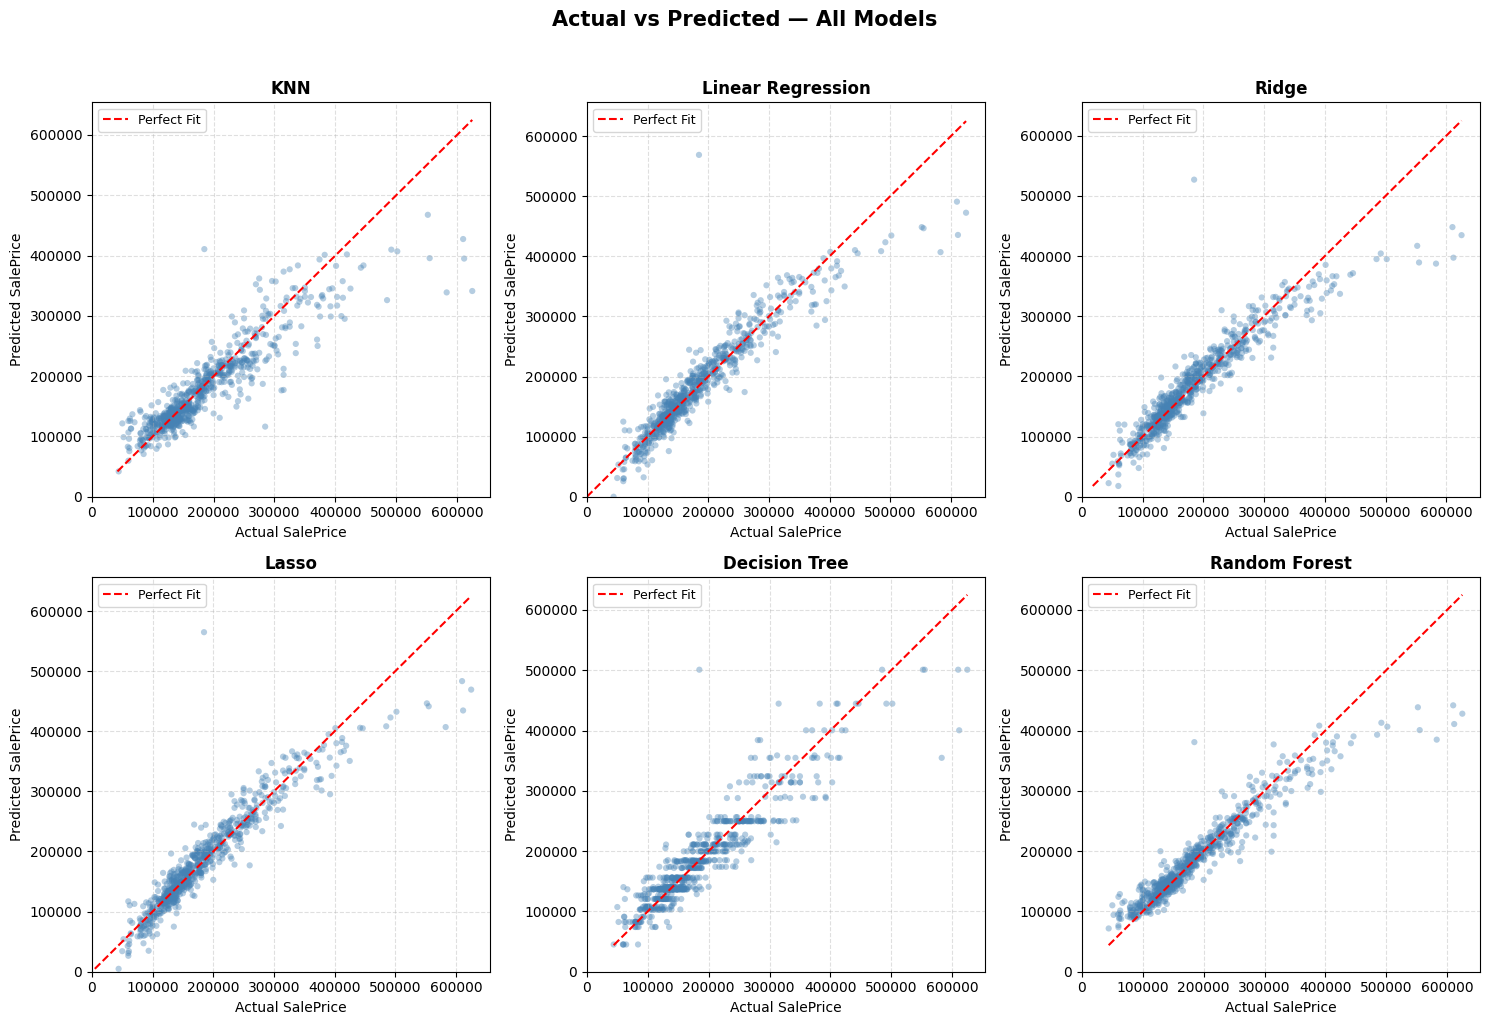

In [504]:
import numpy as np
import matplotlib.pyplot as plt

models = {
    'KNN': (y_test, y_prediction_test_knn),
    'Linear Regression': (y_test, np.clip(y_prediction_test_lr, 0, None)),
    'Ridge': (y_test, np.clip(y_prediction_test_ridge, 0, None)),
    'Lasso': (y_test, np.clip(y_prediction_test_lasso, 0, None)),
    'Decision Tree': (y_test, y_prediction_test_dt),
    'Random Forest': (y_test, y_prediction_test_rfr)
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, (actual, predicted)) in enumerate(models.items()):
    axes[i].scatter(actual, predicted, alpha=0.4, color='steelblue', edgecolors='none', s=20)
    
    min_val = min(actual.min(), max(predicted.min(), 0))
    max_val = max(actual.max(), predicted.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Fit')
    
    axes[i].set_xlim(left=0)
    axes[i].set_ylim(bottom=0)
    
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Actual SalePrice', fontsize=10)
    axes[i].set_ylabel('Predicted SalePrice', fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Actual vs Predicted — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

c:\Users\volca\Desktop\VSCode\Projects\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\volca\Desktop\VSCode\Projects\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


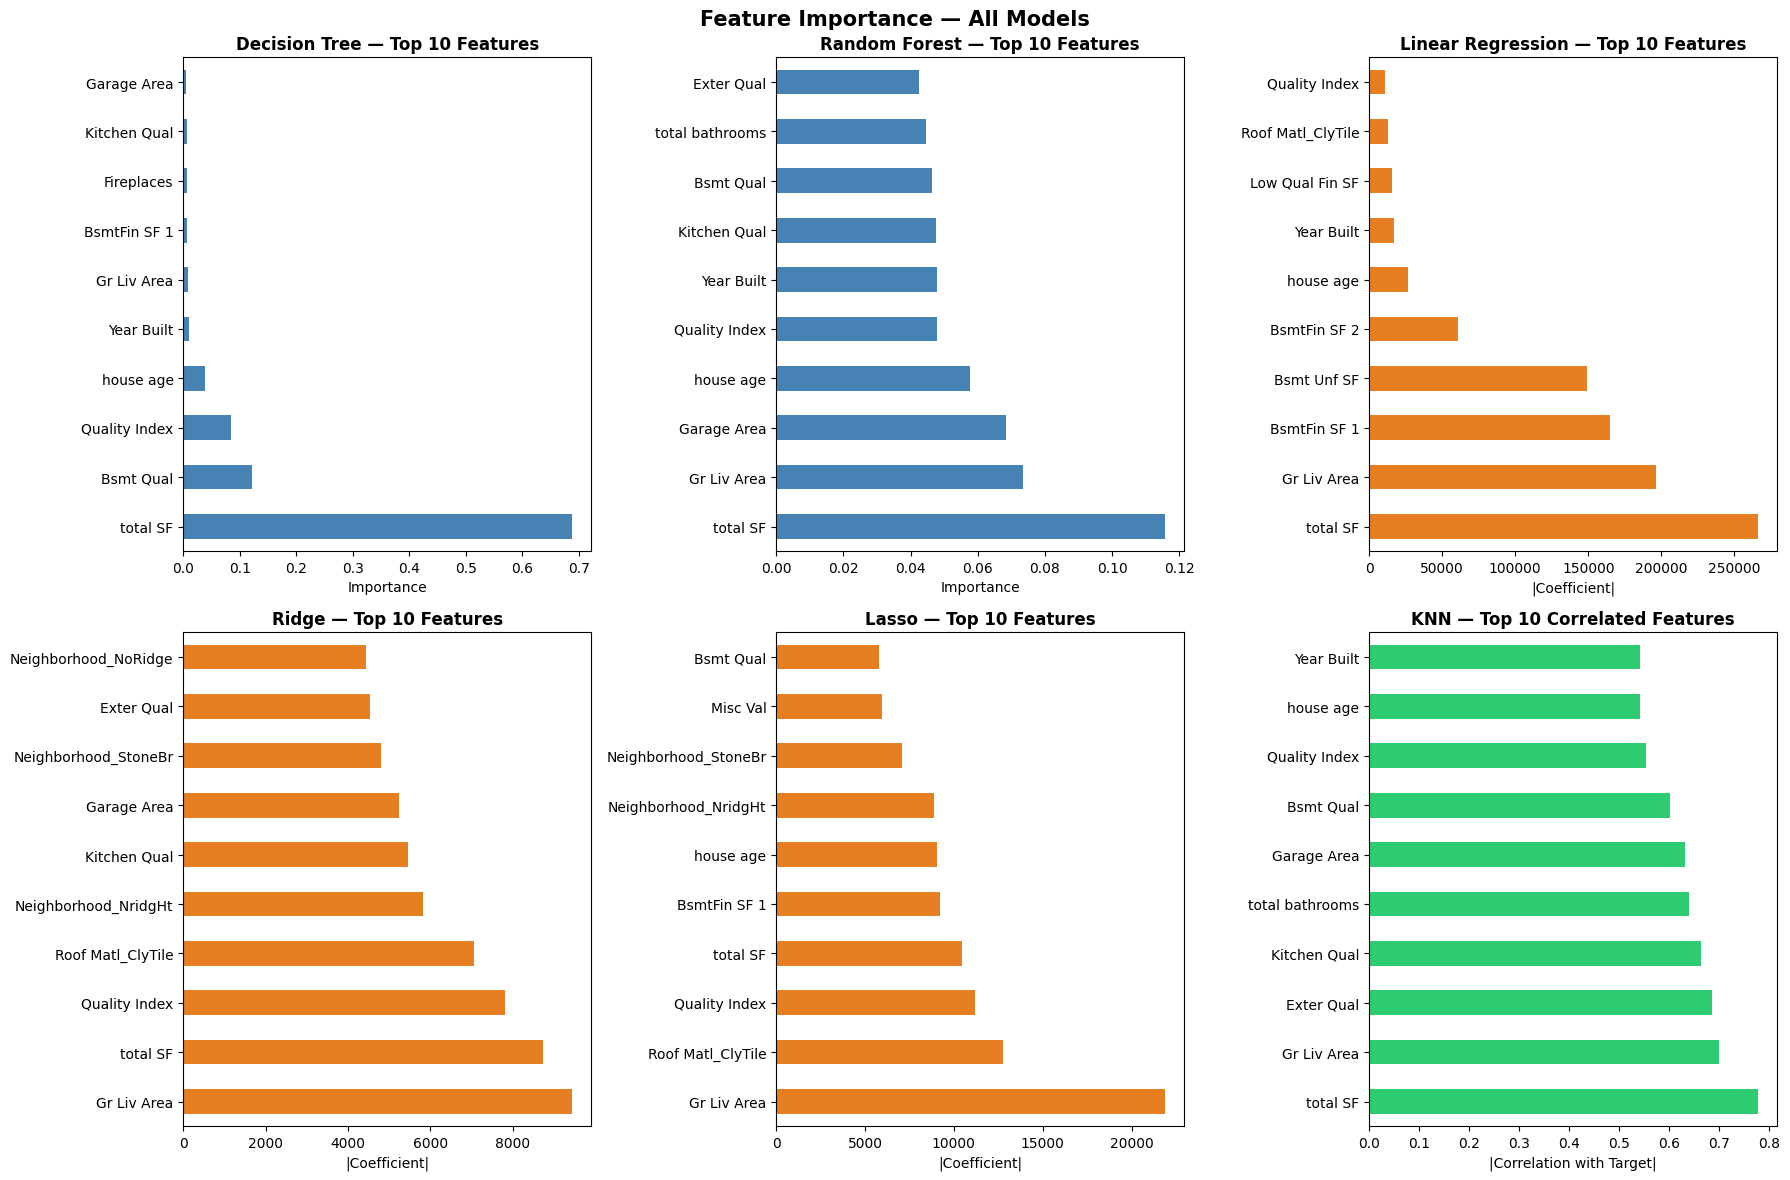

In [505]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.exceptions import NotFittedError

feature_names = x_train.columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

tree_models = {
    'Decision Tree': dt,
    'Random Forest': rf
}

for i, (name, model) in enumerate(tree_models.items()):
    try:
        importances = model.feature_importances_
    except NotFittedError:
        model.fit(x_train, y_train)
        importances = model.feature_importances_

    pd.Series(importances, index=feature_names).nlargest(10).plot(
        kind='barh', ax=axes[i], color='steelblue'
    )
    axes[i].set_title(f'{name} — Top 10 Features', fontweight='bold')
    axes[i].set_xlabel('Importance')

linear_models = {
    'Linear Regression': lr,
    'Ridge': ridge,
    'Lasso': lasso
}

for i, (name, model) in enumerate(linear_models.items(), start=2):
    try:
        coefs = model.coef_
    except NotFittedError:
        model.fit(x_train_scaled, y_train)
        coefs = model.coef_

    pd.Series(np.abs(coefs), index=feature_names).nlargest(10).plot(
        kind='barh', ax=axes[i], color ='#e67e22'
    )
    axes[i].set_title(f'{name} — Top 10 Features', fontweight='bold')
    axes[i].set_xlabel('|Coefficient|')

correlations = pd.DataFrame(x_train, columns=feature_names).corrwith(pd.Series(y_train))
correlations.abs().nlargest(10).plot(kind='barh', ax=axes[5], color='#2ecc71')
axes[5].set_title('KNN — Top 10 Correlated Features', fontweight='bold')
axes[5].set_xlabel('|Correlation with Target|')

plt.suptitle('Feature Importance — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()